<a href="https://colab.research.google.com/github/chandrakalapeddi/coding/blob/main/capston1_minor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Capstone Project 1
# Working with NumPy Matrices (Multidimensional Data)


##**Student Name:** Surya chandrakala Peddi
##**Course:** Data Science



# ***Setup***
Every later step needs these three libraries — NumPy for the matrices, Matplotlib for plots, SciPy for skewness/kurtosis (which plain NumPy doesn't compute).

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)

import numpy as np → Used for matrix and array operations such as finding the mean, standard deviation, sorting, and other mathematical calculations.

import pandas as pd → Used to read CSV files and create DataFrames. It makes handling data with column names easier.

import matplotlib.pyplot as plt → Used to create graphs and plots.

import seaborn as sns → Used mainly for creating a pairplot. It provides more advanced and better-looking plots than Matplotlib.

from scipy import stats → Used to calculate skewness and kurtosis, as these are not directly available in NumPy.

plt.rcParams['figure.figsize'] = (10,6) → Sets the default size of all plots, so there is no need to write the figure size every time.

# Q1 & Q2: Download and load as NumPy matrices
Colab has internet access, so instead of manually downloading the CSVs and uploading them, we read straight from the public GitHub source. pd.read_csv(..., comment='#') automatically skips the descriptive # comment lines at the top of each file and turns the quoted header row into column names; .to_numpy() then converts the result into the plain numeric matrix the assignment asks for. (Per the files' own headers: these are adults 18+, no missing values, from the 2017–March 2020 NHANES cycle — so no cleaning is needed before we start.)

In [65]:
#downloading dataset from url

male_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv"
female_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv"

# loadind the dataset

male = pd.read_csv(male_url, comment='#').to_numpy()
female = pd.read_csv(female_url, comment='#').to_numpy()

column_names = [
    "weight (kg)",
    "standing height (cm)",
    "upper arm length (cm)",
    "upper leg length (cm)",
    "arm circumference (cm)",
    "hip circumference (cm)",
    "waist circumference (cm)"
]

male_df = pd.DataFrame(male, columns=column_names)
female_df = pd.DataFrame(female, columns=column_names)

print("Male — first 5 rows:")
display(male_df.head())

print("\nFemale — first 5 rows:")
display(female_df.head())

Male — first 5 rows:


,weight (kg),standing height (cm),upper arm length (cm),upper leg length (cm),arm circumference (cm),hip circumference (cm),waist circumference (cm)
0,98.8,182.3,42.0,40.1,38.2,108.2,120.4
1,74.3,184.2,41.1,41.0,30.2,94.5,86.8
2,103.7,185.3,47.0,44.0,32.0,107.8,109.6
3,86.0,167.8,39.5,38.4,29.0,106.4,108.3
4,99.4,181.6,40.4,39.9,36.0,120.2,107.0



Female — first 5 rows:


,weight (kg),standing height (cm),upper arm length (cm),upper leg length (cm),arm circumference (cm),hip circumference (cm),waist circumference (cm)
0,97.1,160.2,34.7,40.8,35.8,126.1,117.9
1,91.1,152.7,33.5,33.0,38.5,125.5,103.1
2,73.0,161.2,37.4,38.0,31.8,106.2,92.0
3,61.7,157.4,38.0,34.7,29.0,101.0,90.5
4,55.4,154.6,34.6,34.0,28.3,92.5,73.2


pd.read_csv(url, ...) → Reads the CSV file directly from the internet. Since Google Colab has internet access, the file can be loaded directly from the URL.

comment='#' → Some lines at the beginning of the file start with # and contain dataset information. This parameter ignores those lines, otherwise they may be treated as data and cause an error.

.to_numpy() → Converts a Pandas DataFrame into a NumPy matrix because the assignment requires male and female as NumPy matrices, not DataFrames.

.shape → Checks the number of rows (participants) and columns (7 measurements) in the matrix.

# Q3: Histograms of weight (female top, male bottom)
**plt.subplot** lets us stack two histograms in one figure so they're visually comparable. The shared xlim matters because if the two panels used different x-ranges, a distribution could look wider or narrower purely from axis scaling rather than a real difference — so we compute the limits from the combined min/max of both sexes, rounded outward to clean numbers.

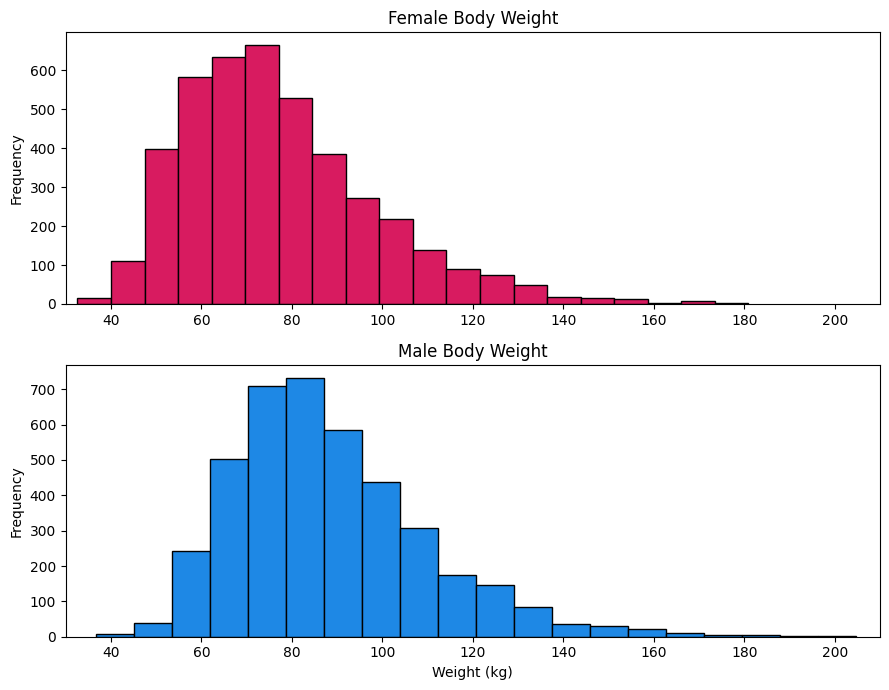

In [66]:
female_weight = female[:, 0]
male_weight = male[:, 0]

xmin = np.floor(min(female_weight.min(), male_weight.min()) / 10) * 10
xmax = np.ceil(max(female_weight.max(), male_weight.max()) / 10) * 10

plt.figure(figsize=(9, 7))

plt.subplot(2, 1, 1)
plt.hist(female_weight, bins=20, color="#d81b60", edgecolor="black")
plt.xlim(xmin, xmax)
plt.title("Female Body Weight")
plt.ylabel("Frequency")

plt.subplot(2, 1, 2)
plt.hist(male_weight, bins=20, color="#1e88e5", edgecolor="black")
plt.xlim(xmin, xmax)
plt.title("Male Body Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

female_weight = female[:, 0]

female[:, 0] → This is matrix indexing. : means all rows, and 0 means column 0 (weight). It extracts the entire weight column as a vector.

xmin = np.floor(min(...) / 10) * 10
min() and max() → Find the lowest and highest weight values from both male and female data.
np.floor() and np.ceil() → Round the values down and up. Dividing by 10, rounding, and then multiplying by 10 gives clean numbers (such as 30, 40, 150) so the x-axis looks neat.

plt.subplot(2, 1, 1)

Creates a grid with 2 rows and 1 column, and places the current plot in the first position (top). The female histogram is on top (2,1,1) and the male histogram is at the bottom (2,1,2).

plt.hist(female_weight, bins=20, ...)

bins=20 → Divides the data into 20 groups (bars). Fewer bins make the graph smoother, while more bins show more detail but can also make the graph look noisy.

plt.xlim(xmin, xmax)

Sets the same x-axis range for both subplots so the comparison is fair. Different axis ranges can make the graphs look misleading.

plt.tight_layout()

When there are multiple subplots, titles and labels may overlap. This function automatically adjusts the spacing so everything is displayed clearly.

# Q4. Boxplot comparing male vs female weight

A boxplot fed a list of two vectors draws two boxes side by side automatically — much more compact than two separate plots for comparing location and spread directly.

/tmp/ipykernel_502/2677711345.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weight, male_weight], labels=["Female", "Male"])


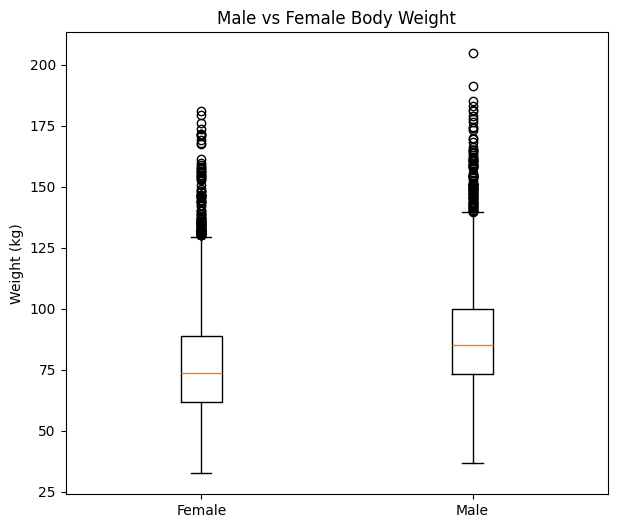

In [67]:
plt.figure(figsize=(7, 6))
plt.boxplot([female_weight, male_weight], labels=["Female", "Male"])
plt.ylabel("Weight (kg)")
plt.title("Male vs Female Body Weight")
plt.show()

boxplot() → If you give it a list of vectors, it creates a separate box for each vector and displays them side by side.

labels= → Displays the names below each box on the x-axis.

# Q5: Numerical aggregates of the two weight distributions
Why: a distribution is fully characterised by three kinds of summary: location (typical value — mean, median), dispersion (spread — std dev, IQR, range), and shape (asymmetry/tails — skewness, kurtosis). Using both a robust and non-robust measure in each category (e.g. median vs mean) also lets you spot skew: if they diverge a lot, the data isn't symmetric.

In [68]:
def describe(x, name):
    print(f"=== {name} ===")
    print(f"Mean:     {np.mean(x):.2f}")
    print(f"Median:   {np.median(x):.2f}")
    print(f"Std dev:  {np.std(x, ddof=1):.2f}")
    print(f"IQR:      {np.percentile(x, 75) - np.percentile(x, 25):.2f}")
    print(f"Range:    {np.ptp(x):.2f}")
    print(f"Skewness: {stats.skew(x):.3f}")
    print(f"Kurtosis: {stats.kurtosis(x):.3f}")  # excess kurtosis, 0 = normal-like
    print()

describe(female_weight, "Female weight")
describe(male_weight, "Male weight")

=== Female weight ===
Mean:     77.40
Median:   73.60
Std dev:  21.55
IQR:      27.10
Range:    148.30
Skewness: 1.033
Kurtosis: 1.401

=== Male weight ===
Mean:     88.36
Median:   85.00
Std dev:  21.42
IQR:      26.50
Range:    167.80
Skewness: 0.984
Kurtosis: 1.474



A function is created so the same code does not have to be written again for both female and male data. Write it once and call it twice.

np.mean(x) → Calculates the average of the data.

np.median(x) → Finds the middle value after sorting the data. It is less affected by outliers than the mean.

np.std(x, ddof=1) → Calculates the standard deviation. ddof=1 means the data is a sample, not the entire population, so it uses n-1 instead of n in the calculation.

np.percentile(x, 75) - np.percentile(x, 25) → Calculates the Interquartile Range (IQR), which shows the spread of the middle 50% of the data. It is not much affected by outliers.

np.ptp(x) → Stands for peak to peak and calculates the range, which is maximum − minimum.

stats.skew(x) → Measures whether the data is symmetric or has a longer tail on one side. A positive value means the right tail is longer.

stats.kurtosis(x) → Measures how heavy the tails of the distribution are compared to a normal distribution. Higher values usually mean there is a greater chance of outliers.

# Q6: Add BMI to the female matrix
BMI = weight(kg) / height(m)². Height is stored in cm, so it must be divided by 100 before squaring. np.column_stack appends BMI as a new 8th column without disturbing the existing 7.

In [69]:
height_m = female[:, 1] / 100
bmi = female[:, 0] / (height_m ** 2)

female = np.column_stack([female, bmi])
print("female shape after adding BMI:", female.shape)
print(female[:5])

female shape after adding BMI: (4221, 8)
[[ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9         37.83504078]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1         39.06972037]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.          28.09265496]
 [ 61.7        157.4         38.          34.7         29.
  101.          90.5         24.90437849]
 [ 55.4        154.6         34.6         34.          28.3
   92.5         73.2         23.17879132]]


female[:, 1] → Selects the height column, which is stored in centimeters (cm).

/100 → Converts the height from centimeters to meters.

**2 → Squares the height (raises it to the power of 2).

Formula: BMI = weight ÷ (height²)

# Q7: Standardise female → zfemale
The 8 columns are on very different scales (kg vs cm), so they aren't directly comparable. Subtracting each column's mean and dividing by its std dev (axis=0 broadcasts this per-column) puts every variable on the same "number of standard deviations from average" scale — which is what makes the pairplot and the extreme-BMI ranking in Q12 meaningful.

In [70]:
zfemale = (female - female.mean(axis=0)) / female.std(axis=0, ddof=1)
print(zfemale[:5].round(3))

[[ 0.914  0.009 -0.567  1.133  0.551  1.083  1.116  0.997]
 [ 0.636 -1.053 -1.079 -1.293  1.032  1.045  0.265  1.156]
 [-0.204  0.151  0.583  0.262 -0.162 -0.191 -0.373 -0.259]
 [-0.729 -0.387  0.839 -0.765 -0.661 -0.523 -0.459 -0.67 ]
 [-1.021 -0.784 -0.61  -0.982 -0.786 -1.067 -1.453 -0.893]]


axis=0 → Performs the operation column-wise, so each column gets its own mean and standard deviation instead of calculating across rows.

This is the z-score formula:

(value − mean) ÷ standard deviation

NumPy automatically uses broadcasting to apply this formula to every row, so there is no need to write a loop.

# Q8: Scatterplot matrix + Pearson/Spearman correlations
These 5 variables (height, weight, waist, hip, BMI) are the ones most tied to body size/shape, so it's natural to check how they move together. We report both correlation types because they answer different questions: Pearson captures linear association and is sensitive to outliers; Spearman captures monotonic rank association and is robust to outliers/non-linearity. A big gap between the two for a given pair is itself informative (hints the relationship isn't simply linear).

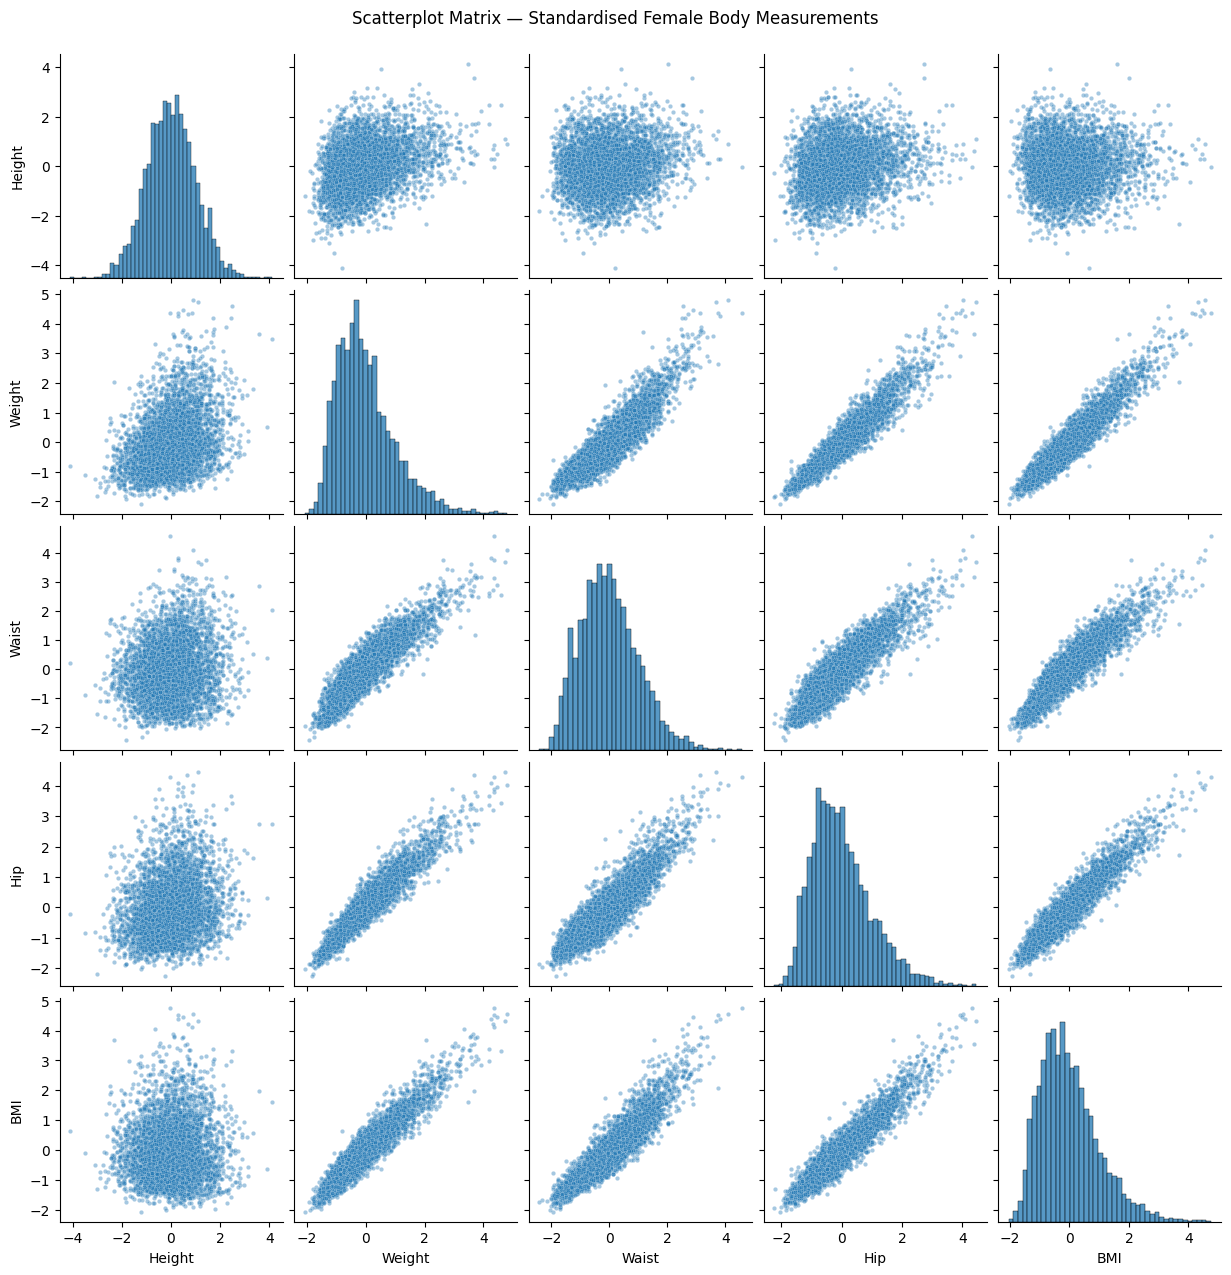

Pearson correlation:
         Height  Weight  Waist    Hip    BMI
Height   1.000   0.345  0.127  0.203  0.033
Weight   0.345   1.000  0.905  0.947  0.946
Waist    0.127   0.905  1.000  0.897  0.921
Hip      0.203   0.947  0.897  1.000  0.944
BMI      0.033   0.946  0.921  0.944  1.000

Spearman correlation:
         Height  Weight  Waist    Hip    BMI
Height   1.000   0.339  0.109  0.205  0.020
Weight   0.339   1.000  0.900  0.947  0.938
Waist    0.109   0.900  1.000  0.888  0.923
Hip      0.205   0.947  0.888  1.000  0.934
BMI      0.020   0.938  0.923  0.934  1.000


In [71]:
cols = [1, 0, 6, 5, 7]  # height, weight, waist, hip, BMI
labels = ["Height", "Weight", "Waist", "Hip", "BMI"]
df_z = pd.DataFrame(zfemale[:, cols], columns=labels)

sns.pairplot(df_z, diag_kind="hist", plot_kws={"s": 10, "alpha": 0.4})
plt.suptitle("Scatterplot Matrix — Standardised Female Body Measurements", y=1.02)
plt.show()

print("Pearson correlation:\n", df_z.corr(method="pearson").round(3))
print("\nSpearman correlation:\n", df_z.corr(method="spearman").round(3))

This is the list of column indices from zfemale that are needed: height (1), weight (0), waist (6), hip (5), and BMI (7).

sns.pairplot(df_z, diag_kind="hist", ...)

This is a Seaborn function that automatically creates a scatter plot for every pair of variables in a grid. On the diagonal, it shows a histogram for each variable. This is called a scatter plot matrix or pairplot.

df_z.corr(method="pearson")

df_z.corr(method="spearman")

.corr() → Creates a correlation matrix, which shows the strength of the relationship between every pair of variables. The values range from -1 to +1.

Pearson correlation → Measures only linear relationships and is more affected by outliers.

Spearman correlation → Is based on the rank of the data. It checks whether one variable consistently increases or decreases as the other changes. The relationship does not have to be linear, and it is less affected by outliers.

# Q9: Waist-to-height and waist-to-hip ratios
dividing waist by height (or by hip) cancels out a person's overall size, so the resulting ratio reflects fat distribution/shape rather than absolute size. We apply the same function to both matrices so male and female stay directly comparable.

In [72]:
def add_ratios(m):
    height = m[:, 1]
    hip = m[:, 5]
    waist = m[:, 6]
    whtr = waist / height
    whr = waist / hip
    return np.column_stack([m, whtr, whr])

male = add_ratios(male)
female = add_ratios(female)
print("male shape:", male.shape, "| female shape:", female.shape)

male shape: (4081, 9) | female shape: (4221, 10)


A function is created so the same logic can be used for both the male and female matrices without writing the same code again.

waist / height and waist / hip are calculated using simple division to create two new ratio columns. These new columns are then added to the matrix using np.column_stack().

# Q10: Boxplot of both ratios, both sexes
Same idea as Q4, just extended to four groups in one call so location/spread across sex and ratio-type can be read off a single chart.

/tmp/ipykernel_502/2566919603.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


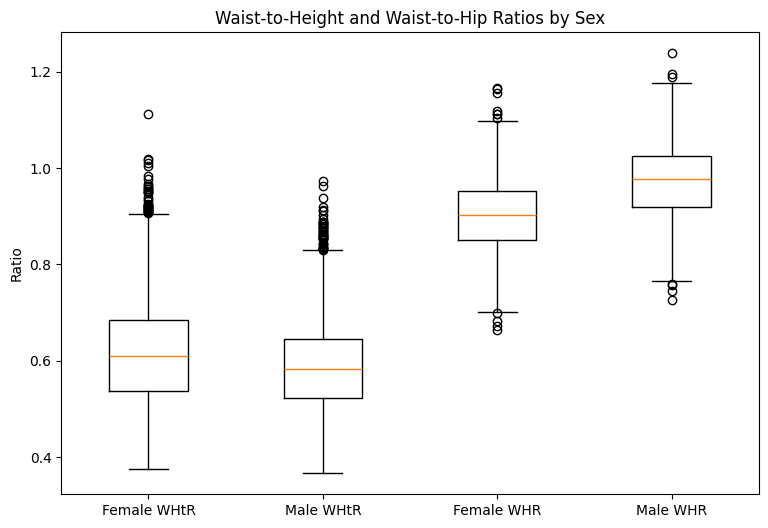

In [73]:
plt.figure(figsize=(9, 6))
plt.boxplot(
    [female[:, 8], male[:, 7], female[:, 9], male[:, 8]],
    labels=["Female WHtR", "Male WHtR", "Female WHR", "Male WHR"]
)
plt.ylabel("Ratio")
plt.title("Waist-to-Height and Waist-to-Hip Ratios by Sex")
plt.show()

# Q11: BMI vs WHtR vs WHR

**BMI**— Pros: needs only weight and height, extremely well-studied, has established population cutoffs, cheap to measure. Cons: can't distinguish muscle from fat mass (misclassifies muscular people as overweight) and says nothing about where fat is stored.

**Waist-to-height ratio (WHtR)** — Pros: captures abdominal/visceral fat, which is more strongly linked to cardiometabolic risk than overall size; a single ~0.5 cutoff works reasonably across sexes and ethnicities. Cons: waist circumference is measured less consistently in practice than height or weight; still just a proxy, not a direct fat measurement.

**Waist-to-hip ratio (WHR)**— Pros: explicitly captures body-shape/fat-distribution pattern, historically used as a cardiovascular risk flag. Cons: combines two measurement points (more compounded measurement error); hip circumference is influenced by bone/muscle structure as well as fat, so WHR can be a noisier signal than WHtR.

# Q12: Standardised measurements of the 5 lowest/highest-BMI women
 np.argsort ranks all row indices by BMI ascending. Because z-scoring preserves rank order, sorting by the raw BMI column gives the same participant order as sorting by zfemale's BMI column — so we sort once and reuse the indices to pull rows from zfemale.

In [74]:
bmi_col = 7  # BMI's position in zfemale

order = np.argsort(female[:, bmi_col])
lowest5_idx = order[:5]
highest5_idx = order[-5:][::-1]

col_names = ["weight", "height", "up_arm_len", "up_leg_len",
             "arm_circ", "hip_circ", "waist_circ", "BMI"]

print("5 lowest-BMI participants (standardised):")
print(pd.DataFrame(zfemale[lowest5_idx], columns=col_names).round(2))

print("\n5 highest-BMI participants (standardised):")
print(pd.DataFrame(zfemale[highest5_idx], columns=col_names).round(2))

5 lowest-BMI participants (standardised):
   weight  height  up_arm_len  up_leg_len  arm_circ  hip_circ  waist_circ  \
0   -2.08   -1.22       -1.55       -1.17     -2.19     -2.04       -1.94   
1   -1.88   -0.19       -1.72        0.39     -2.44     -1.85       -2.06   
2   -1.54    1.81        0.63        0.57     -2.27     -1.68       -1.71   
3   -1.84   -0.26       -0.23        0.51     -2.30     -2.25       -1.86   
4   -1.61    0.89       -0.10        0.48     -2.21     -1.83       -1.71   

    BMI  
0 -2.05  
1 -1.99  
2 -1.97  
3 -1.94  
4 -1.89  

5 highest-BMI participants (standardised):
   weight  height  up_arm_len  up_leg_len  arm_circ  hip_circ  waist_circ  \
0    4.36   -0.03       -0.06       -0.17      2.78      4.32        4.57   
1    4.80    0.89        2.12        1.82      3.78      4.02        4.08   
2    4.35    0.28        2.84        1.94      4.37      3.92        3.75   
3    4.46    0.50        1.69       -1.14      3.35      3.98        2.90   
4    4

In [75]:
column_names = [
    "weight (kg)",
    "standing height (cm)",
    "upper arm length (cm)",
    "upper leg length (cm)",
    "arm circumference (cm)",
    "hip circumference (cm)",
    "waist circumference (cm)",
    "BMI"
]

bmi_col = 7  # BMI zfemale mein 8th column hai (index 7)

order = np.argsort(female[:, bmi_col])   # BMI ke hisaab se sabhi rows ke index, ascending order mein
lowest5_idx = order[:5]                  # sabse kam BMI wale 5 log
highest5_idx = order[-5:][::-1]          # sabse zyada BMI wale 5 log (highest sabse pehle)

lowest5_df = pd.DataFrame(zfemale[lowest5_idx], columns=column_names).round(2)
highest5_df = pd.DataFrame(zfemale[highest5_idx], columns=column_names).round(2)

print("5 LOWEST-BMI participants (standardised z-scores):")
display(lowest5_df)

print("\n5 HIGHEST-BMI participants (standardised z-scores):")
display(highest5_df)

5 LOWEST-BMI participants (standardised z-scores):


,weight (kg),standing height (cm),upper arm length (cm),upper leg length (cm),arm circumference (cm),hip circumference (cm),waist circumference (cm),BMI
0,-2.08,-1.22,-1.55,-1.17,-2.19,-2.04,-1.94,-2.05
1,-1.88,-0.19,-1.72,0.39,-2.44,-1.85,-2.06,-1.99
2,-1.54,1.81,0.63,0.57,-2.27,-1.68,-1.71,-1.97
3,-1.84,-0.26,-0.23,0.51,-2.30,-2.25,-1.86,-1.94
4,-1.61,0.89,-0.10,0.48,-2.21,-1.83,-1.71,-1.89



5 HIGHEST-BMI participants (standardised z-scores):


,weight (kg),standing height (cm),upper arm length (cm),upper leg length (cm),arm circumference (cm),hip circumference (cm),waist circumference (cm),BMI
0,4.36,-0.03,-0.06,-0.17,2.78,4.32,4.57,4.76
1,4.80,0.89,2.12,1.82,3.78,4.02,4.08,4.54
2,4.35,0.28,2.84,1.94,4.37,3.92,3.75,4.51
3,4.46,0.50,1.69,-1.14,3.35,3.98,2.90,4.46
4,4.25,0.29,1.86,-0.98,2.37,4.10,3.82,4.40


In [76]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=lowest5_df)

https://docs.google.com/spreadsheets/d/1ljkcg33ILiQFPUXdF-DgRbg2xnWhPwWVYOB9mU6L0x8/edit#gid=0


np.argsort() → It does not sort the values. Instead, it returns the original index positions of the values in sorted order (from smallest to largest). This means order[0] is the index of the row with the lowest BMI.

lowest5_idx = order[:5]

highest5_idx = order[-5:][::-1]

order[:5] → Gets the indices of the 5 lowest BMI values.

order[-5:] → Gets the indices of the 5 highest BMI values (the last 5 in the sorted list).

[::-1] → Reverses the list so the highest BMI appears first.

zfemale[lowest5_idx]

This is called fancy indexing. It uses a list of indices to select specific rows from the matrix all at once.